## Descriptive Statistics Analysis

This notebook performs a comprehensive descriptive statistics analysis on your uploaded CSV dataset. We will use `pandas` for data manipulation, `numpy` for numerical operations, and `matplotlib` and `seaborn` for data visualization. The analysis is structured into three main sections: Measures of Central Tendency, Measures of Variability, and Measures of Frequency Distribution.

First, let's import the necessary libraries and load the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load the CSV file into a pandas DataFrame ---
file_path = '/content/drive/MyDrive/Colab Notebooks/TPSM/dimension_02_stage_01_preprocessing.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from: {file_path}\n")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the file path is correct and the file is accessible.\n")
    # Exit or handle the error appropriately, e.g., create an empty DataFrame
    df = pd.DataFrame()

if not df.empty:
    # --- 2. Display the first few rows of the dataset ---
    print("### First 5 Rows of the Dataset:")
    display(df.head())
    print("\n" + "-" * 50 + "\n")

    # --- 3. Show dataset shape, column names, data types, and missing values ---
    print("### Dataset Information:\n")
    print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

    print("Column Names and Data Types:")
    display(df.info())
    print("\n" + "-" * 50 + "\n")

    print("Missing Values (Number of NaNs per Column):")
    missing_values = df.isnull().sum()
    display(missing_values[missing_values > 0].to_frame(name='Missing Values'))
    if missing_values.sum() == 0:
        print("No missing values found in the dataset.")
    print("\n" + "-" * 50 + "\n")

    # --- 4. Separate numeric columns and categorical columns ---
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

    print("Numeric Columns:", numeric_cols)
    print("Categorical Columns:", categorical_cols)
else:
    print("Data loading failed, proceeding with an empty DataFrame. Please fix the file path or ensure the file exists.")


Successfully loaded data from: /content/drive/MyDrive/Colab Notebooks/TPSM/dimension_02_stage_01_preprocessing.csv

### First 5 Rows of the Dataset:


,issue_category,customer_sentiment,issue_complexity,agent_experience_level,agent_politeness,agent_empathy,agent_professionalism,communication_clarity,apology_present,patience_present,active_listening_present,deescalation_present,helpfulness,customer_tone_observed,outcome_quality,retention_label
0,Pickup and Shipping,neutral,less,junior,high,present,high,high,0,1,1,0,high,neutral,resolved,retained
1,Mobile Number and Email Verification,neutral,medium,junior,high,present,medium,high,1,1,1,1,high,neutral,resolved,retained
2,Replacement and Return Process,neutral,medium,experienced,high,present,high,high,1,1,1,1,high,neutral,resolved,retained
3,Login Issues and Error Messages,neutral,less,inexperienced,high,present,medium,high,1,1,1,1,high,neutral,resolved,retained
4,Order Delivery Issues,negative,medium,experienced,high,present,high,high,1,1,1,1,high,negative,partially_resolved,not_retained



--------------------------------------------------

### Dataset Information:

Dataset Shape: 1000 rows, 16 columns

Column Names and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   issue_category            1000 non-null   object
 1   customer_sentiment        1000 non-null   object
 2   issue_complexity          1000 non-null   object
 3   agent_experience_level    1000 non-null   object
 4   agent_politeness          1000 non-null   object
 5   agent_empathy             1000 non-null   object
 6   agent_professionalism     1000 non-null   object
 7   communication_clarity     1000 non-null   object
 8   apology_present           1000 non-null   int64 
 9   patience_present          1000 non-null   int64 
 10  active_listening_present  1000 non-null   int64 
 11  deescalation_present      1000 non-null  

None


--------------------------------------------------

Missing Values (Number of NaNs per Column):


,Missing Values


No missing values found in the dataset.

--------------------------------------------------

Numeric Columns: ['apology_present', 'patience_present', 'active_listening_present', 'deescalation_present']
Categorical Columns: ['issue_category', 'customer_sentiment', 'issue_complexity', 'agent_experience_level', 'agent_politeness', 'agent_empathy', 'agent_professionalism', 'communication_clarity', 'helpfulness', 'customer_tone_observed', 'outcome_quality', 'retention_label']


# SECTION 1: Measures of Central Tendency

This section calculates the mean, median, and mode for all numeric columns in the dataset. These measures help us understand the typical or central value of our data.

In [2]:
if not df.empty and numeric_cols:
    print("### Calculating Measures of Central Tendency for Numeric Columns:\n")

    # --- 5. Compute mean, median, and mode for all numeric columns ---
    mean_values = df[numeric_cols].mean()
    median_values = df[numeric_cols].median()

    # Mode can return multiple values, so we handle it slightly differently
    mode_values_dict = {}
    for col in numeric_cols:
        # dropna=False to count NaN as a potential mode if it's the most frequent
        modes = df[col].mode(dropna=False)
        if len(modes) > 1:
            mode_values_dict[col] = ', '.join(map(str, modes.tolist()))
        elif len(modes) == 1:
            mode_values_dict[col] = modes[0]
        else:
            mode_values_dict[col] = 'No mode'
    mode_series = pd.Series(mode_values_dict)

    # Combine into a single DataFrame for display
    central_tendency_df = pd.DataFrame({
        'Mean': mean_values,
        'Median': median_values,
        'Mode': mode_series
    })

    print("Measures of Central Tendency:")
    display(central_tendency_df)

    # --- 12. Save the summary tables as CSV files ---
    central_tendency_df.to_csv('central_tendency_summary.csv', index=True)
    print("\nSummary of Central Tendency saved to 'central_tendency_summary.csv'.")
else:
    print("No numeric columns found or DataFrame is empty to calculate central tendency.")


### Calculating Measures of Central Tendency for Numeric Columns:

Measures of Central Tendency:


,Mean,Median,Mode
apology_present,0.791,1.0,1
patience_present,0.960,1.0,1
active_listening_present,0.988,1.0,1
deescalation_present,0.675,1.0,1



Summary of Central Tendency saved to 'central_tendency_summary.csv'.


# SECTION 2: Measures of Variability

This section calculates the range, variance, standard deviation, and Interquartile Range (IQR) for all numeric columns. These measures describe the spread or dispersion of the data.

In [3]:
if not df.empty and numeric_cols:
    print("### Calculating Measures of Variability for Numeric Columns:\n")

    # --- 6. Compute range, variance, standard deviation, and IQR for all numeric columns ---
    range_values = df[numeric_cols].max() - df[numeric_cols].min()
    variance_values = df[numeric_cols].var()
    std_dev_values = df[numeric_cols].std()
    iqr_values = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)

    # Combine into a single DataFrame for display
    variability_df = pd.DataFrame({
        'Range': range_values,
        'Variance': variance_values,
        'Standard Deviation': std_dev_values,
        'IQR': iqr_values
    })

    print("Measures of Variability:")
    display(variability_df)

    # --- 12. Save the summary tables as CSV files ---
    variability_df.to_csv('variability_summary.csv', index=True)
    print("\nSummary of Variability saved to 'variability_summary.csv'.")
else:
    print("No numeric columns found or DataFrame is empty to calculate variability.")


### Calculating Measures of Variability for Numeric Columns:

Measures of Variability:


,Range,Variance,Standard Deviation,IQR
apology_present,1,0.165484,0.406798,0.0
patience_present,1,0.038438,0.196057,0.0
active_listening_present,1,0.011868,0.108940,0.0
deescalation_present,1,0.219595,0.468609,1.0



Summary of Variability saved to 'variability_summary.csv'.


# SECTION 3: Measures of Frequency Distribution

This section visualizes the distribution of data using histograms for numeric columns, boxplots for numeric columns, and pie charts for categorical columns. These plots help us understand the shape, spread, and common values within our data.

### Histograms for Numeric Columns:



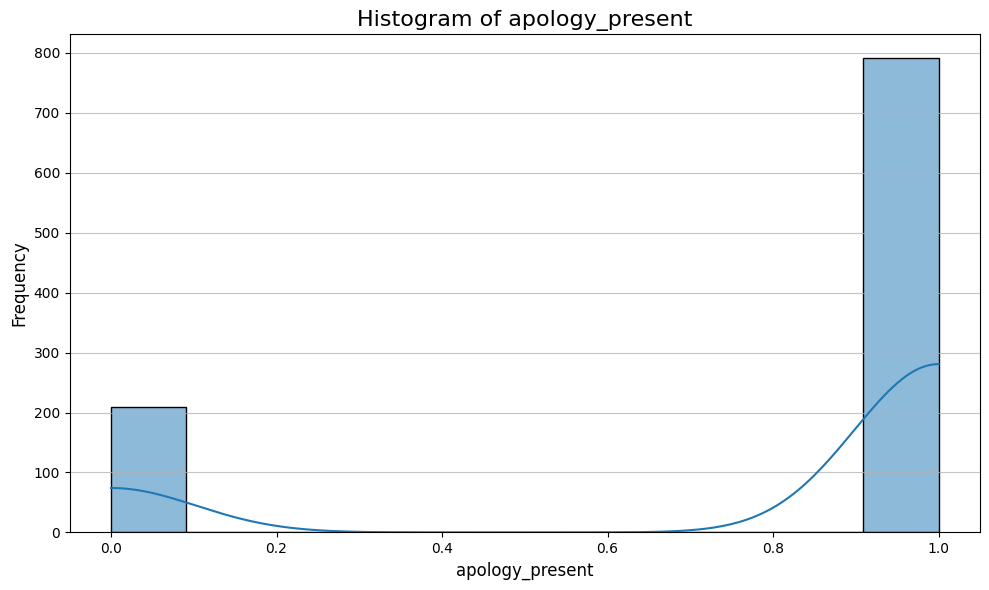


----------------------------------------------------------------------



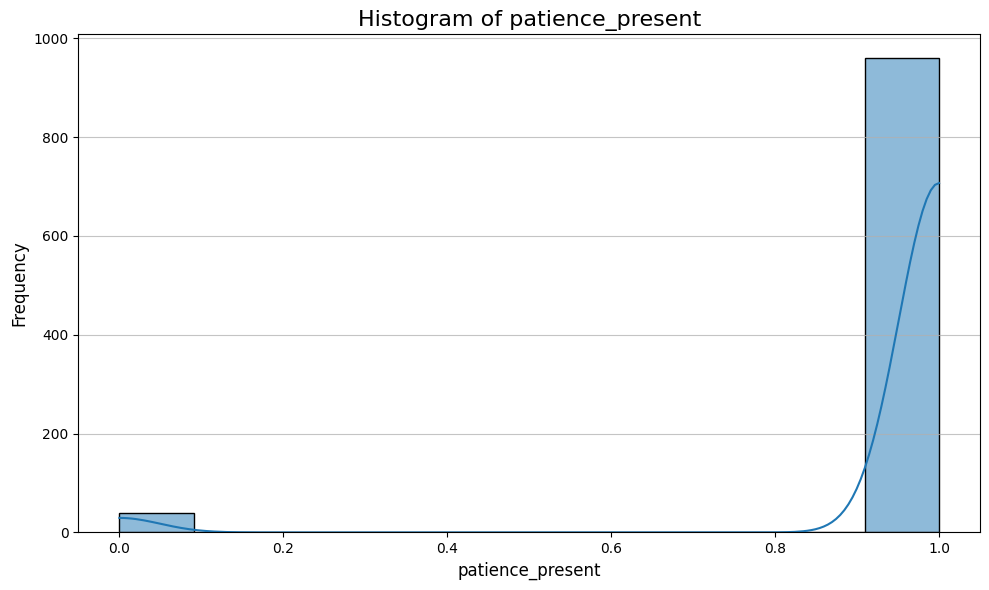


----------------------------------------------------------------------



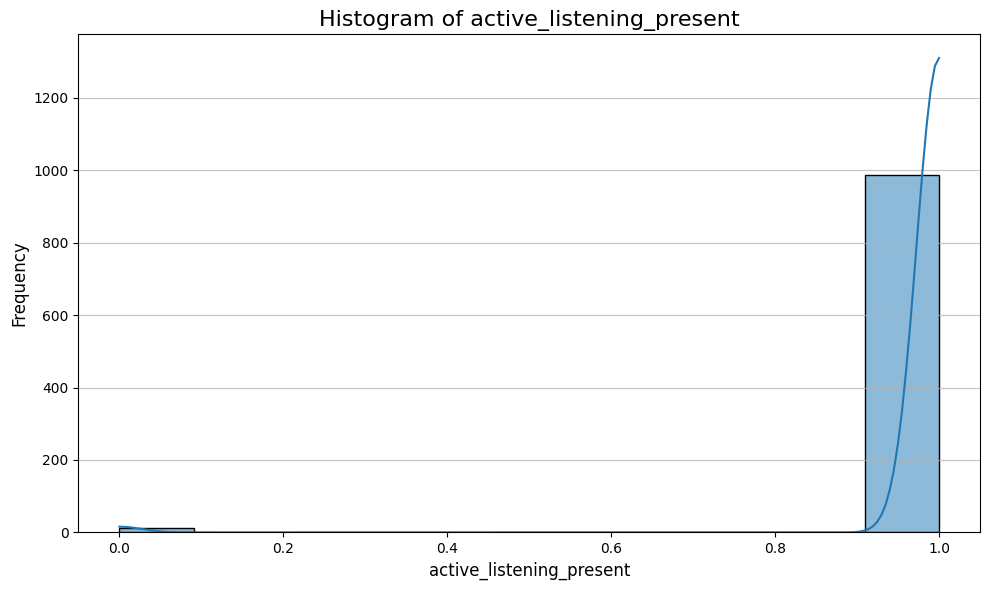


----------------------------------------------------------------------



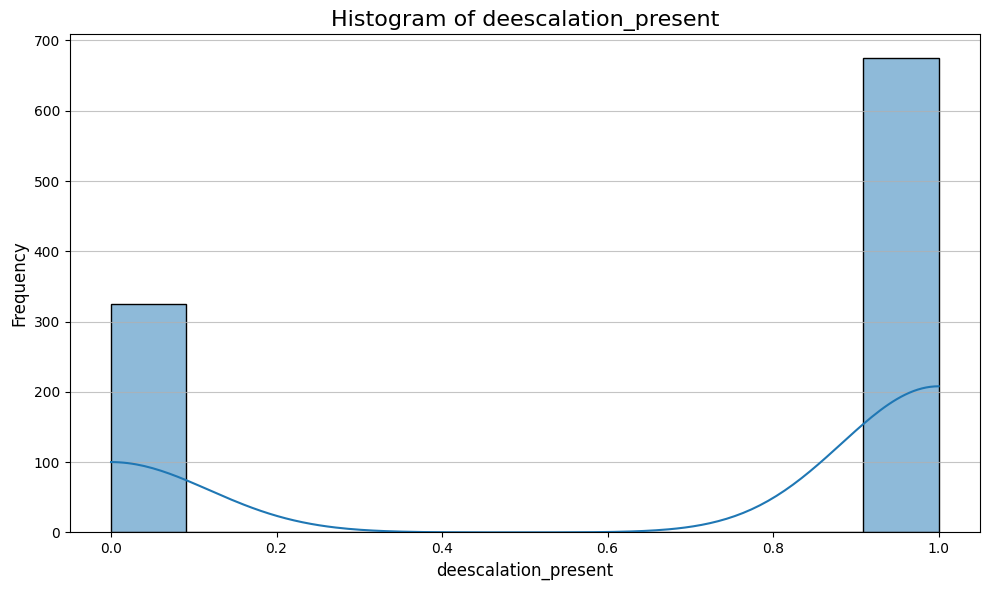


----------------------------------------------------------------------



In [4]:
if not df.empty and numeric_cols:
    print("### Histograms for Numeric Columns:\n")

    # --- 7. Plot histograms for numeric columns ---
    for col in numeric_cols:
        plt.figure(figsize=(10, 6)) # Larger figure size
        sns.histplot(df[col].dropna(), kde=True) # dropna to handle potential NaNs safely
        plt.title(f'Histogram of {col}', fontsize=16) # Proper title
        plt.xlabel(col, fontsize=12) # X-axis label
        plt.ylabel('Frequency', fontsize=12) # Y-axis label
        plt.grid(axis='y', alpha=0.75) # Add grid for readability
        plt.tight_layout() # Adjust layout to prevent labels from overlapping
        plt.show()
        print("\n" + "-" * 70 + "\n") # Spacing
else:
    print("No numeric columns found or DataFrame is empty to plot histograms.")


### Boxplots for Numeric Columns:



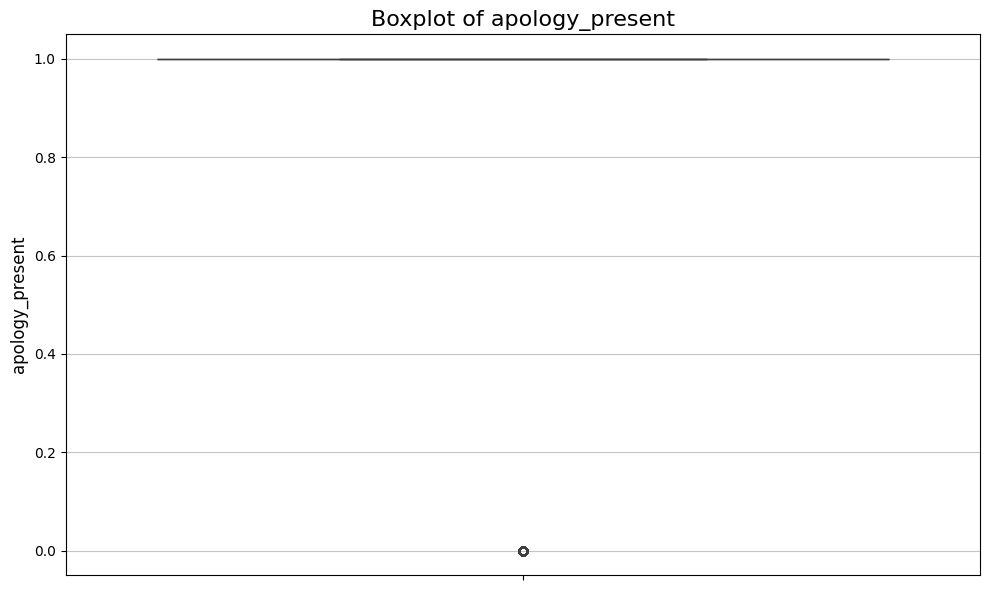


----------------------------------------------------------------------



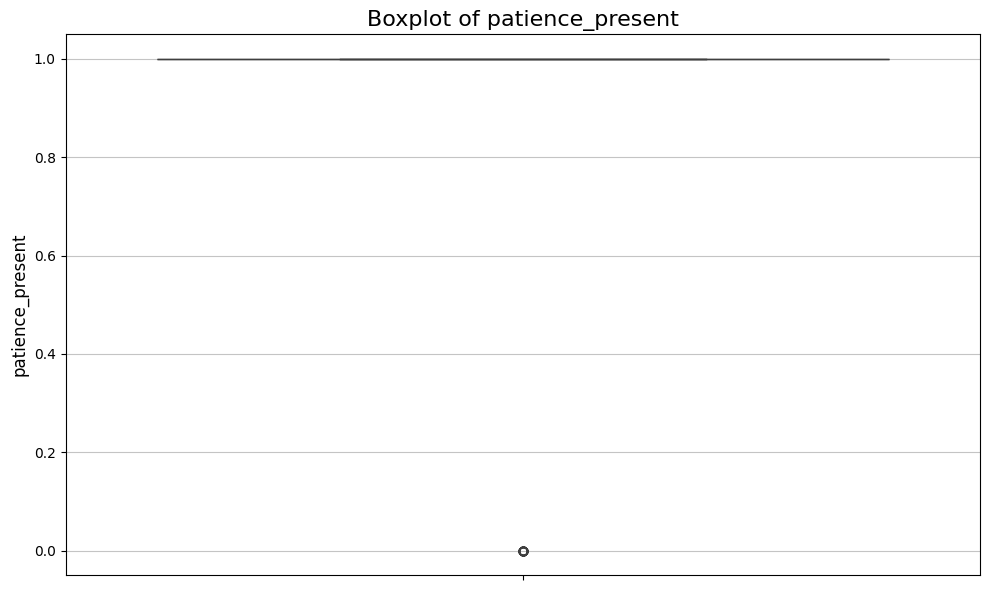


----------------------------------------------------------------------



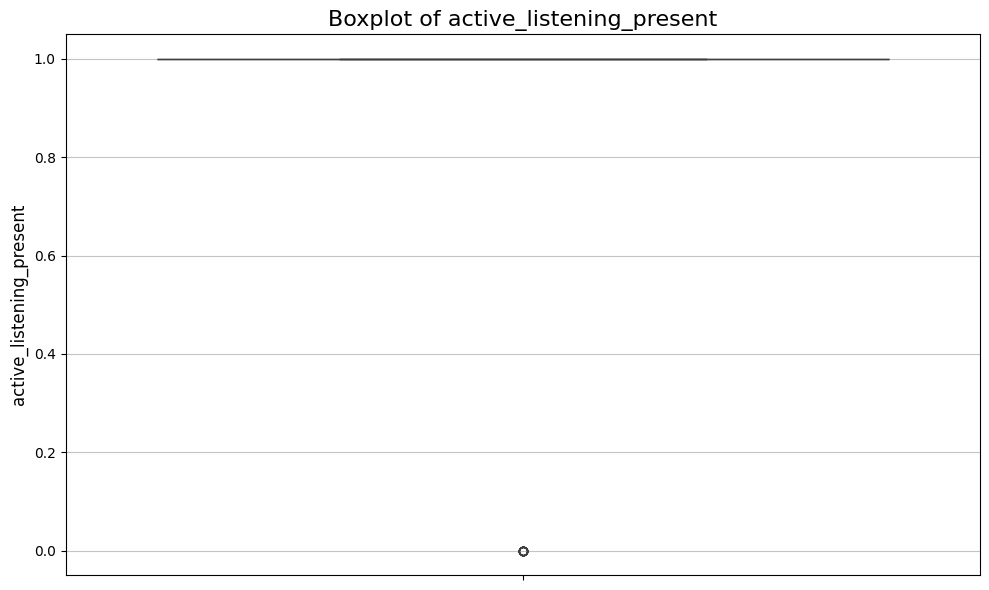


----------------------------------------------------------------------



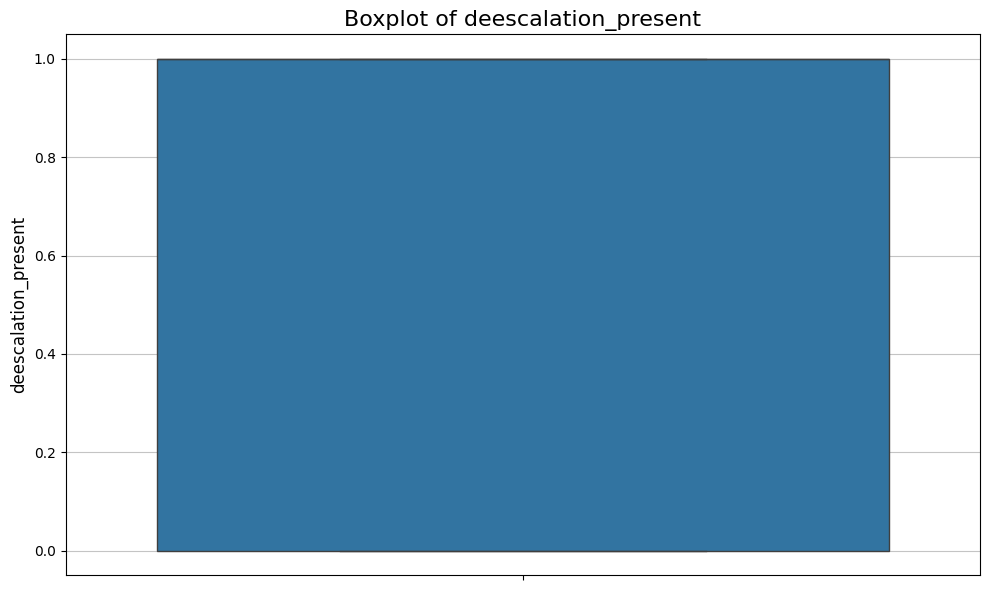


----------------------------------------------------------------------



In [5]:
if not df.empty and numeric_cols:
    print("### Boxplots for Numeric Columns:\n")

    # --- 8. Plot boxplots for numeric columns ---
    for col in numeric_cols:
        plt.figure(figsize=(10, 6)) # Larger figure size
        sns.boxplot(y=df[col].dropna()) # dropna to handle potential NaNs safely
        plt.title(f'Boxplot of {col}', fontsize=16) # Proper title
        plt.ylabel(col, fontsize=12) # Y-axis label
        plt.grid(axis='y', alpha=0.75) # Add grid for readability
        plt.tight_layout()
        plt.show()
        print("\n" + "-" * 70 + "\n") # Spacing
else:
    print("No numeric columns found or DataFrame is empty to plot boxplots.")


### Pie Charts for Categorical Columns:



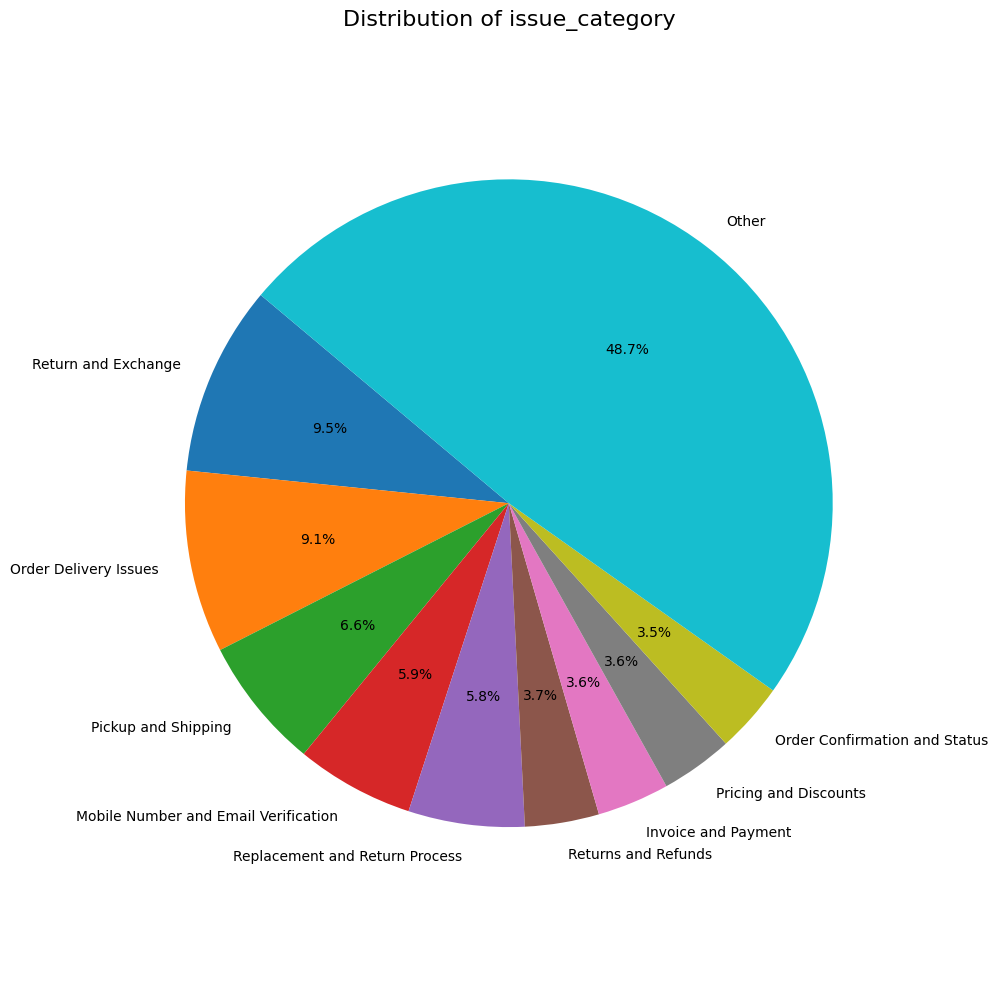


----------------------------------------------------------------------



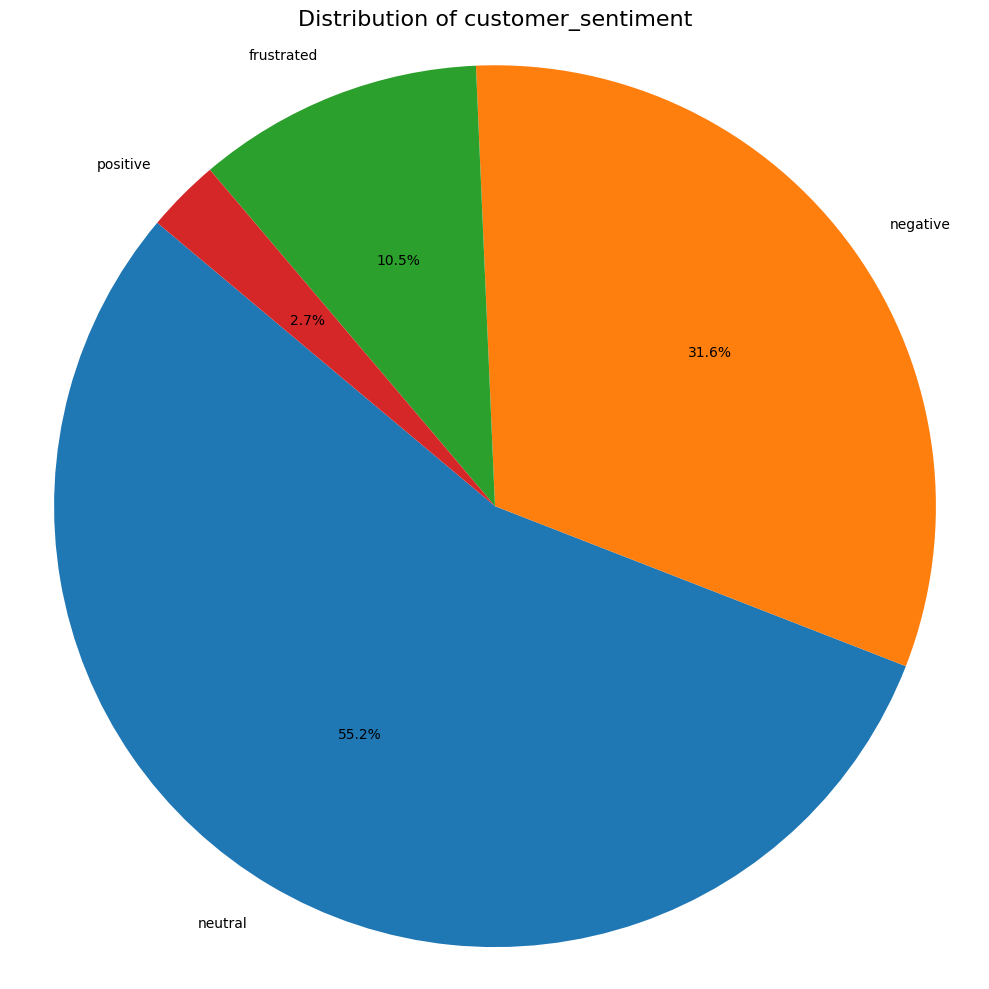


----------------------------------------------------------------------



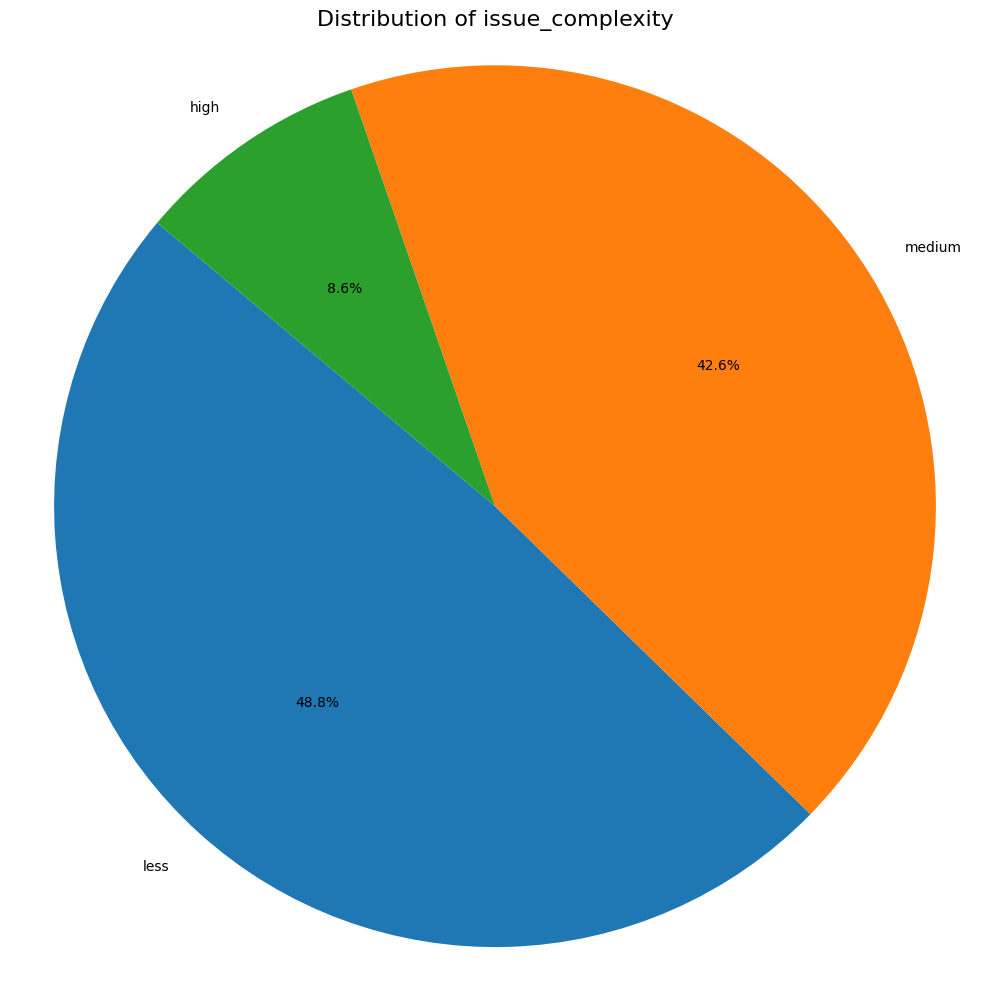


----------------------------------------------------------------------



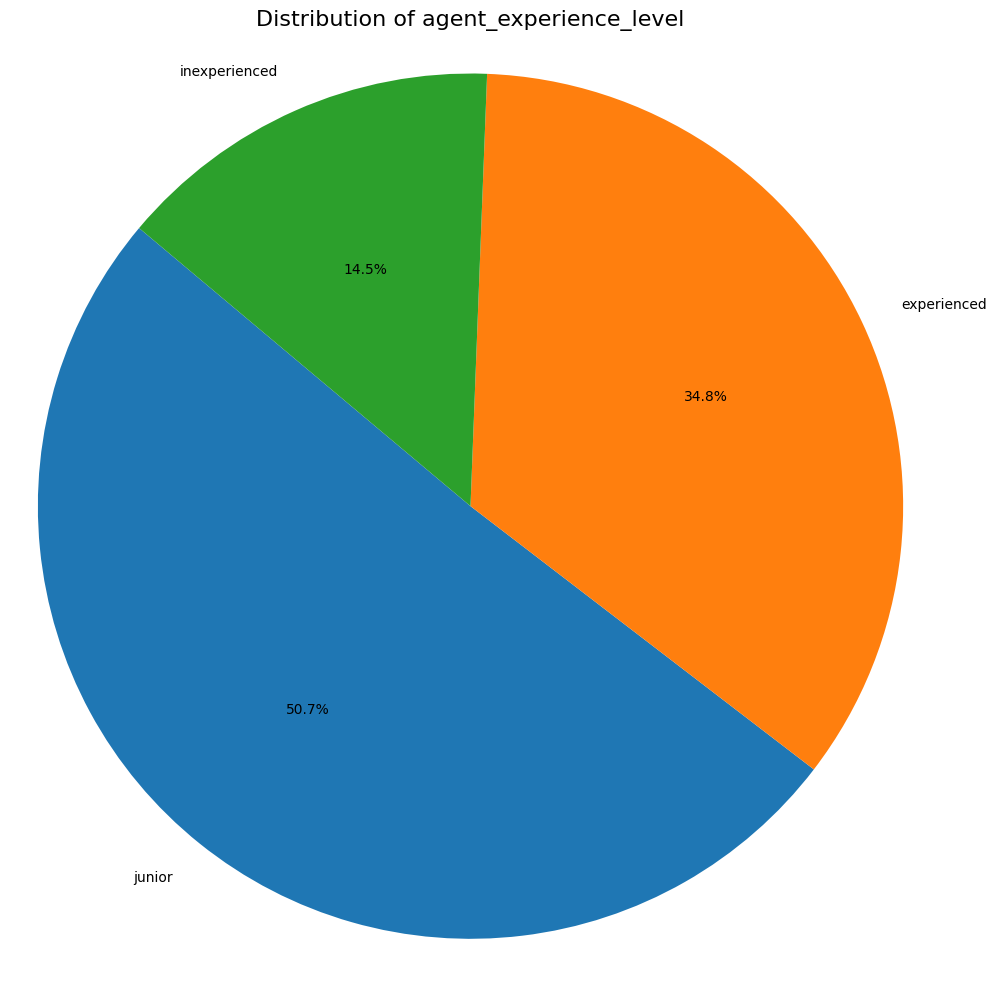


----------------------------------------------------------------------



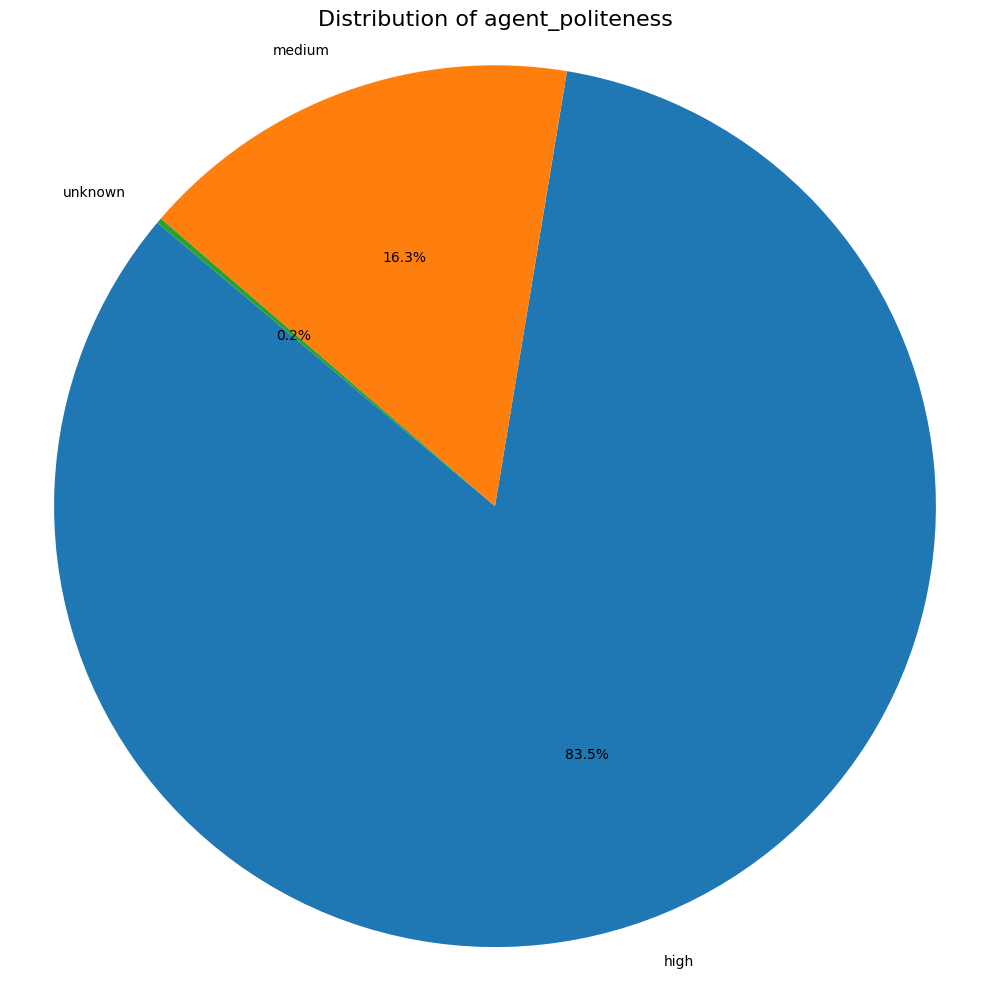


----------------------------------------------------------------------



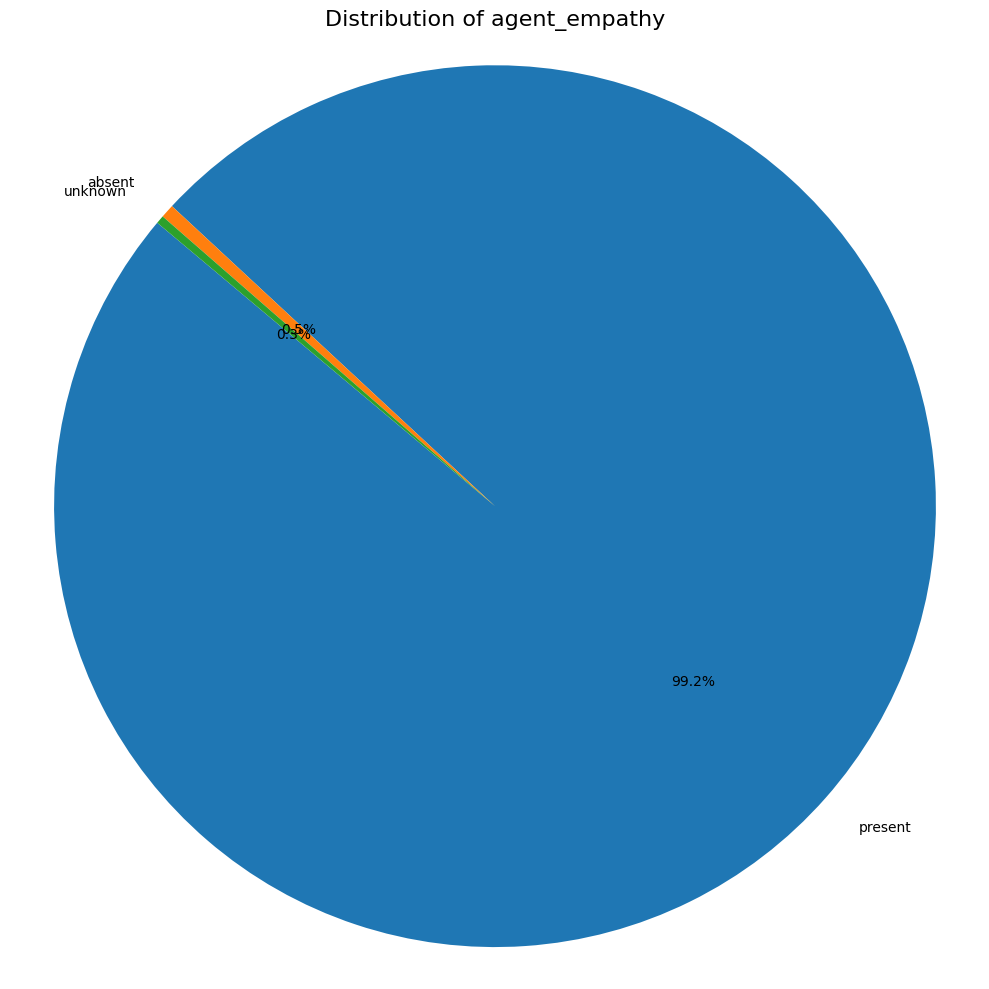


----------------------------------------------------------------------



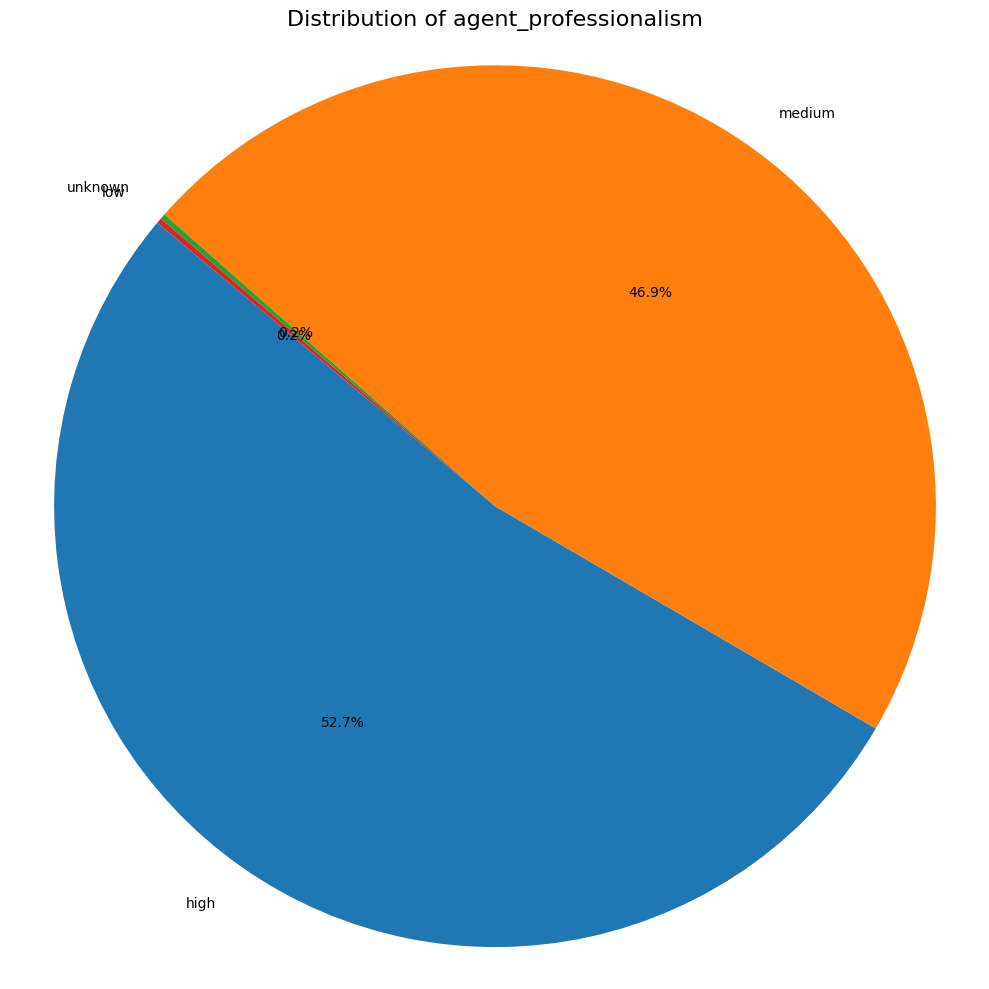


----------------------------------------------------------------------



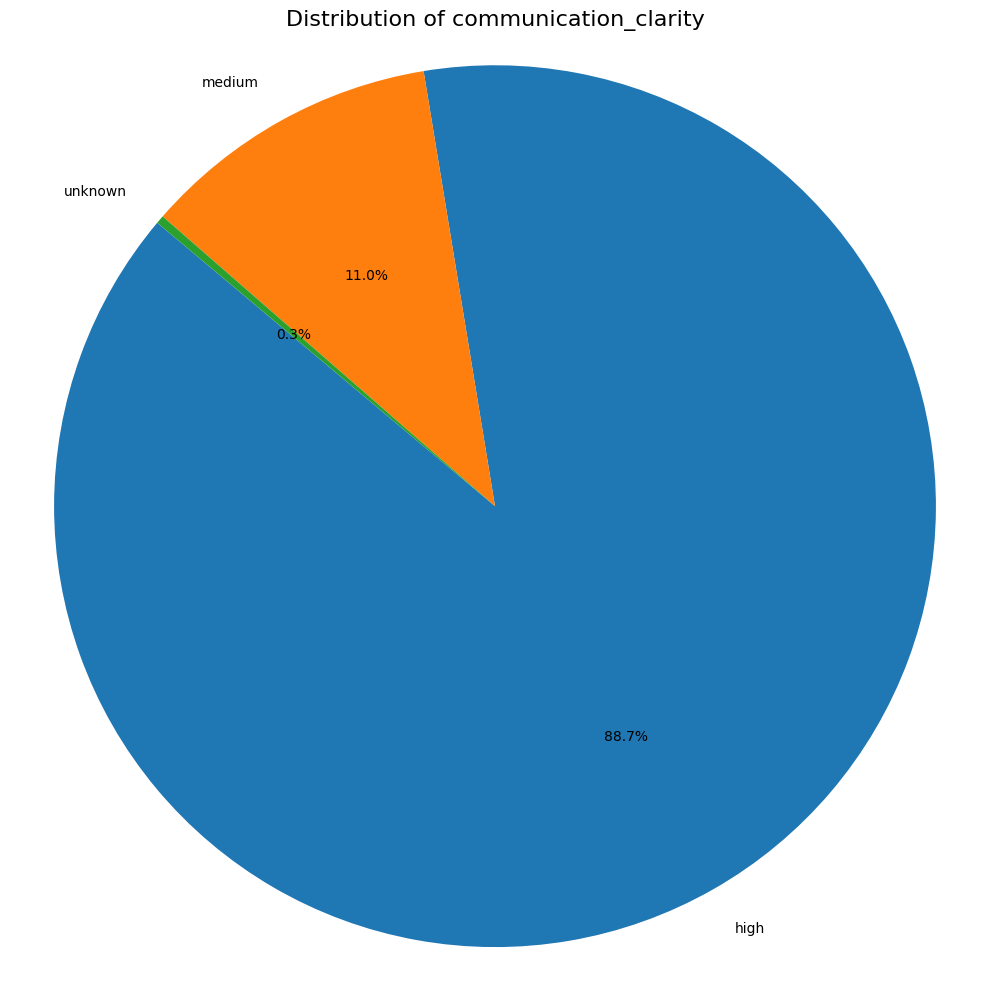


----------------------------------------------------------------------



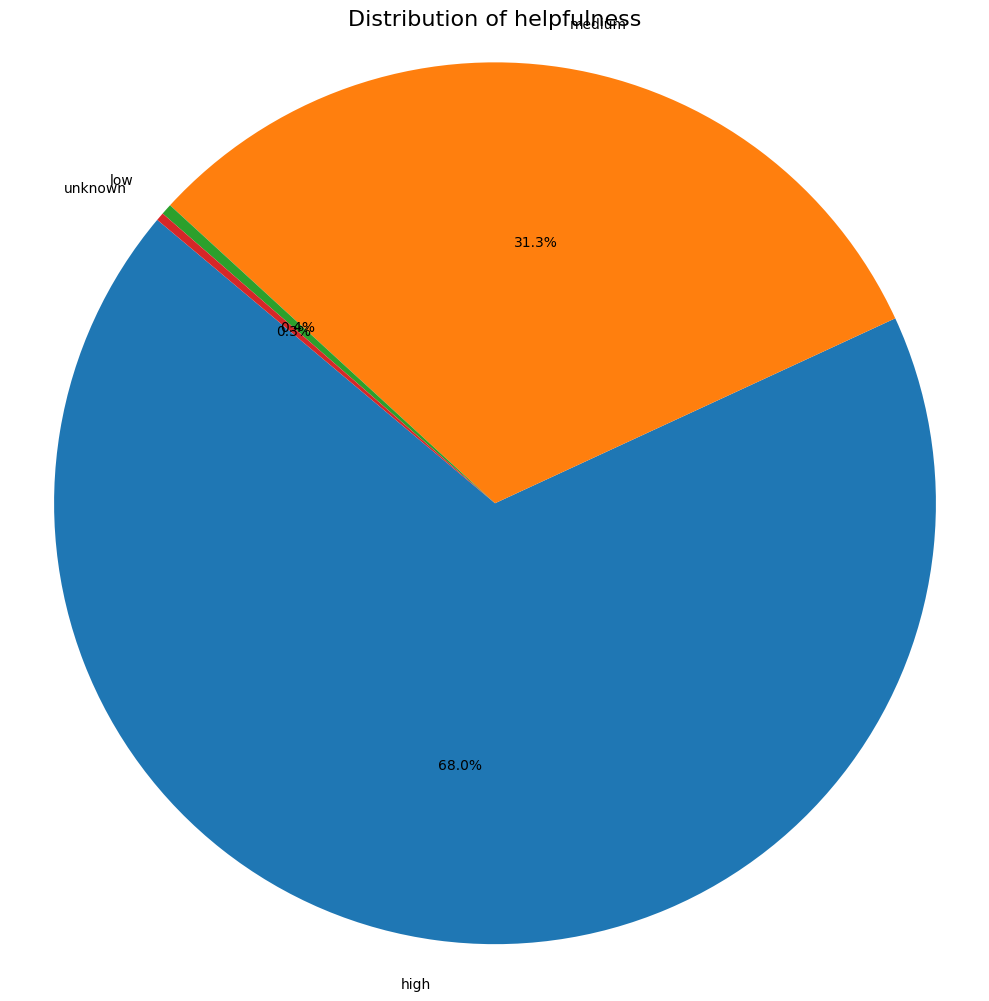


----------------------------------------------------------------------



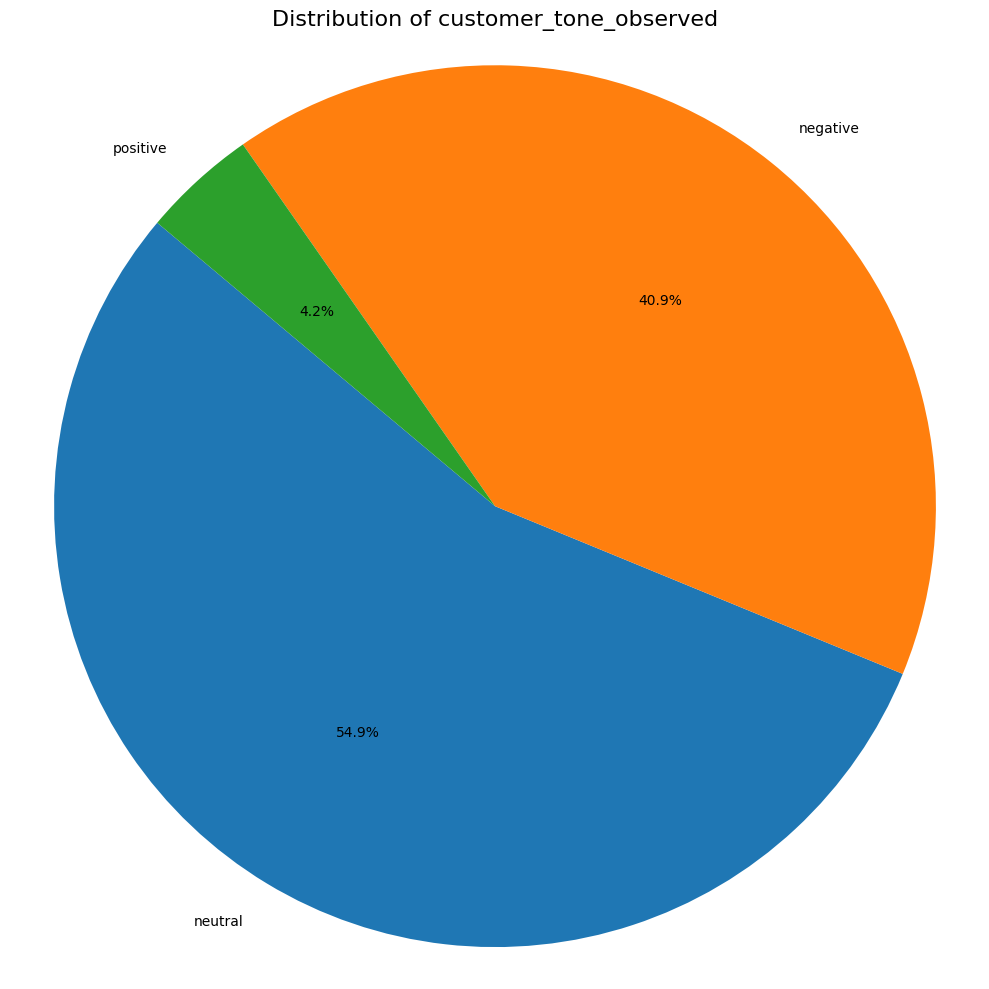


----------------------------------------------------------------------



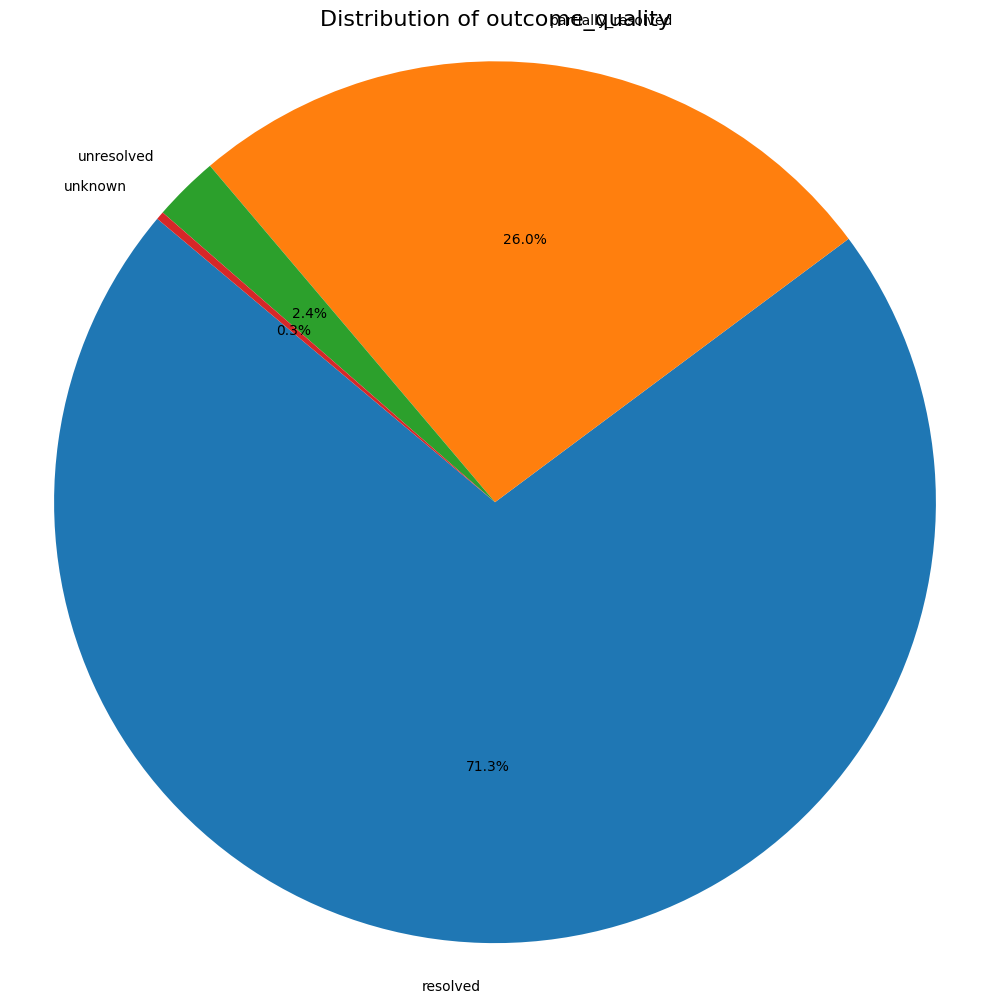


----------------------------------------------------------------------



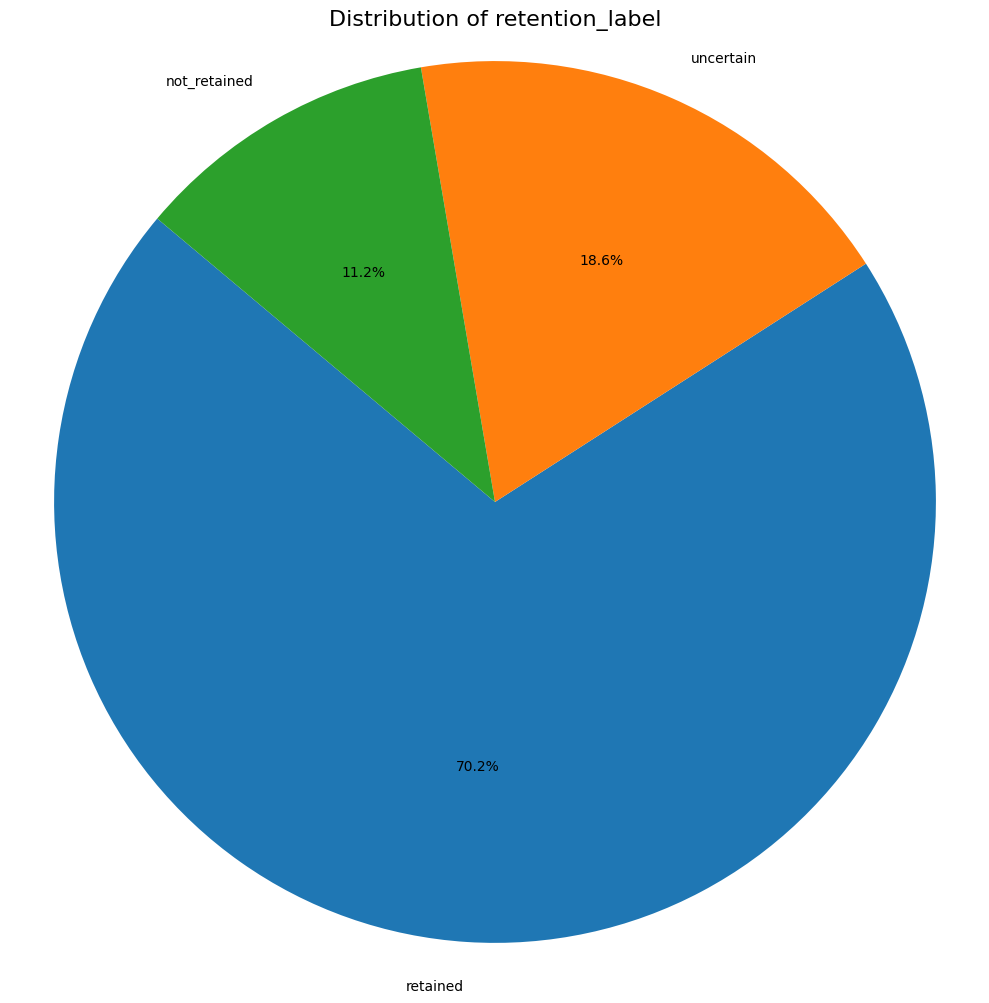


----------------------------------------------------------------------



In [6]:
if not df.empty and categorical_cols:
    print("### Pie Charts for Categorical Columns:\n")

    # --- 9. Plot pie charts for categorical columns ---
    for col in categorical_cols:
        # Count values and handle missing values by filling them or dropping for the plot
        value_counts = df[col].value_counts(dropna=False)

        # Limit to top categories if there are too many unique values
        if len(value_counts) > 10: # Example: limit to top 10 categories
            top_categories = value_counts.head(9)
            other_count = value_counts.iloc[9:].sum()
            value_counts = pd.concat([top_categories, pd.Series({'Other': other_count})])

        # Ensure there are values to plot
        if not value_counts.empty and value_counts.sum() > 0:
            plt.figure(figsize=(10, 10)) # Larger figure size for pie charts
            plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=140)
            plt.title(f'Distribution of {col}', fontsize=16) # Proper title
            plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
            plt.tight_layout()
            plt.show()
            print("\n" + "-" * 70 + "\n") # Spacing
        else:
            print(f"Skipping pie chart for '{col}' as it has no valid data to plot.\n")
else:
    print("No categorical columns found or DataFrame is empty to plot pie charts.")


## Explanation of the Code

This section explains each part of the Python code used for the descriptive statistics analysis:

### 1. Library Imports and Data Loading
-   `import pandas as pd`: Imports the pandas library, essential for data manipulation and analysis, aliased as `pd` for convenience.
-   `import numpy as np`: Imports the NumPy library, which provides support for large, multi-dimensional arrays and mathematical functions, aliased as `np`.
-   `import matplotlib.pyplot as plt`: Imports the `pyplot` module from Matplotlib, used for creating static, interactive, and animated visualizations in Python, aliased as `plt`.
-   `import seaborn as sns`: Imports the Seaborn library, which is built on Matplotlib and provides a high-level interface for drawing attractive and informative statistical graphics.
-   `file_path = '...'`: Defines the path to your CSV file.
-   `df = pd.read_csv(file_path)`: Reads the CSV file into a pandas DataFrame named `df`. A `try-except` block is used to gracefully handle `FileNotFoundError`.

### 2. Initial Data Inspection
-   `display(df.head())`: Shows the first 5 rows of the DataFrame, giving a quick preview of the data.
-   `print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")`: Prints the number of rows and columns in the DataFrame.
-   `display(df.info())`: Provides a concise summary of the DataFrame, including column names, non-null counts, and data types, which is useful for identifying missing values and incorrect data types.
-   `missing_values = df.isnull().sum()` and `display(missing_values[missing_values > 0].to_frame(name='Missing Values'))`: Calculates and displays the count of missing values (NaNs) for each column. If there are no missing values, a corresponding message is printed.
-   `numeric_cols = df.select_dtypes(include=np.number).columns.tolist()`: Identifies and stores the names of columns with numeric data types.
-   `categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()`: Identifies and stores the names of columns with non-numeric (e.g., object, string) data types.

### 3. SECTION 1: Measures of Central Tendency
-   **Mean (`df[numeric_cols].mean()`):** Calculates the arithmetic average of values for each numeric column.
-   **Median (`df[numeric_cols].median()`):** Finds the middle value of each numeric column when sorted. It's less affected by outliers than the mean.
-   **Mode (`df[col].mode(dropna=False)`):** Determines the most frequently occurring value(s) in each numeric column. `dropna=False` ensures that `NaN` values are considered if they are the most frequent. The code handles cases with multiple modes or no mode gracefully.
-   **`pd.DataFrame({...})` and `display()`:** These lines combine the calculated mean, median, and mode into a single structured DataFrame for clear presentation.
-   **`central_tendency_df.to_csv(...)`:** Saves the central tendency summary to a CSV file.

### 4. SECTION 2: Measures of Variability
-   **Range (`df[numeric_cols].max() - df[numeric_cols].min()`):** Computes the difference between the maximum and minimum values in each numeric column, indicating the total spread.
-   **Variance (`df[numeric_cols].var()`):** Measures how much values in each numeric column deviate from the mean, on average, squared.
-   **Standard Deviation (`df[numeric_cols].std()`):** The square root of the variance, providing a measure of data dispersion in the same units as the data itself.
-   **Interquartile Range (IQR) (`df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)`):** Calculates the difference between the 75th percentile (Q3) and the 25th percentile (Q1) of each numeric column. It represents the middle 50% of the data and is robust to outliers.
-   **`pd.DataFrame({...})` and `display()`:** These lines combine the calculated variability measures into a single structured DataFrame for clear presentation.
-   **`variability_df.to_csv(...)`:** Saves the variability summary to a CSV file.

### 5. SECTION 3: Measures of Frequency Distribution
-   **Histograms (for Numeric Columns):**
    -   `plt.figure(figsize=(10, 6))`: Sets a large figure size for better readability of plots.
    -   `sns.histplot(df[col].dropna(), kde=True)`: Creates a histogram using Seaborn. `dropna()` ensures that missing values are not plotted. `kde=True` adds a Kernel Density Estimate line, which estimates the probability density function of the variable.
    -   `plt.title()`, `plt.xlabel()`, `plt.ylabel()`: Set appropriate titles and axis labels for each plot.
    -   `plt.grid()`: Adds a grid to the plot for easier interpretation.
    -   `plt.tight_layout()`: Adjusts plot parameters for a tight layout, preventing labels from overlapping.
    -   `plt.show()`: Displays the plot.

-   **Boxplots (for Numeric Columns):**
    -   `plt.figure(figsize=(10, 6))`: Sets a large figure size.
    -   `sns.boxplot(y=df[col].dropna())`: Generates a boxplot for each numeric column. Boxplots display the distribution of data based on a five-number summary: minimum, first quartile (Q1), median, third quartile (Q3), and maximum. Outliers are plotted as individual points.
    -   Similar `plt.title()`, `plt.ylabel()`, `plt.grid()`, `plt.tight_layout()`, `plt.show()` are used for proper formatting and display.

-   **Pie Charts (for Categorical Columns):**
    -   `value_counts = df[col].value_counts(dropna=False)`: Counts the occurrences of each unique value in a categorical column. `dropna=False` ensures that missing values are counted if present.
    -   The code includes logic to limit the number of categories displayed in the pie chart (e.g., top 9 categories + 'Other') if there are too many unique values, to maintain readability.
    -   `plt.figure(figsize=(10, 10))`: Sets a large, square figure size suitable for pie charts.
    -   `plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=140)`: Creates a pie chart. `labels` are the category names, `autopct` formats the percentage displayed on each slice, and `startangle` rotates the start of the first slice.
    -   `plt.title()`, `plt.axis('equal')`, `plt.tight_layout()`, `plt.show()` are used for proper formatting and display.